In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
df=pd.read_csv("Exam_Score_Prediction.csv")

In [3]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [4]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(20000, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [9]:
df.drop("student_id",axis=1,inplace=True)

<Axes: xlabel='exam_score', ylabel='Count'>

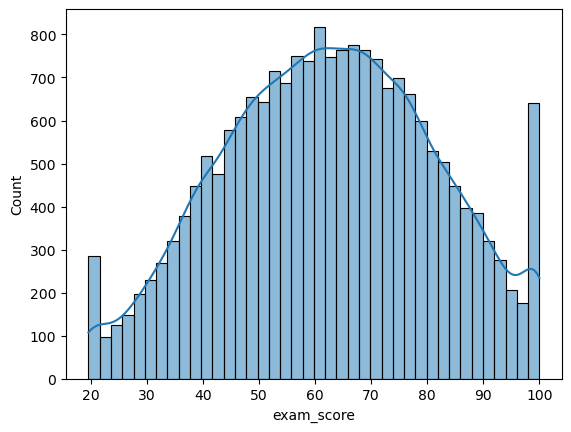

In [12]:
sns.histplot(df['exam_score'],kde=True)

<Axes: xlabel='age', ylabel='exam_score'>

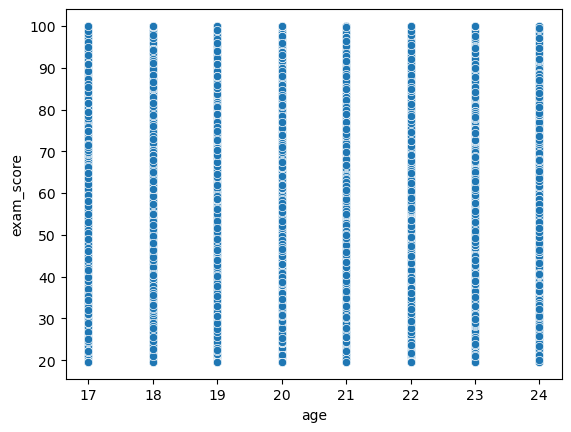

In [13]:
sns.scatterplot(x=df['age'],y=df['exam_score'])

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print(numerical_cols)
print(categorical_cols)

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score'], dtype='object')
Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


### TO CHECK DISTRIBUTION OF NUMERICAL COLUMNS HISTPLOT IS USED


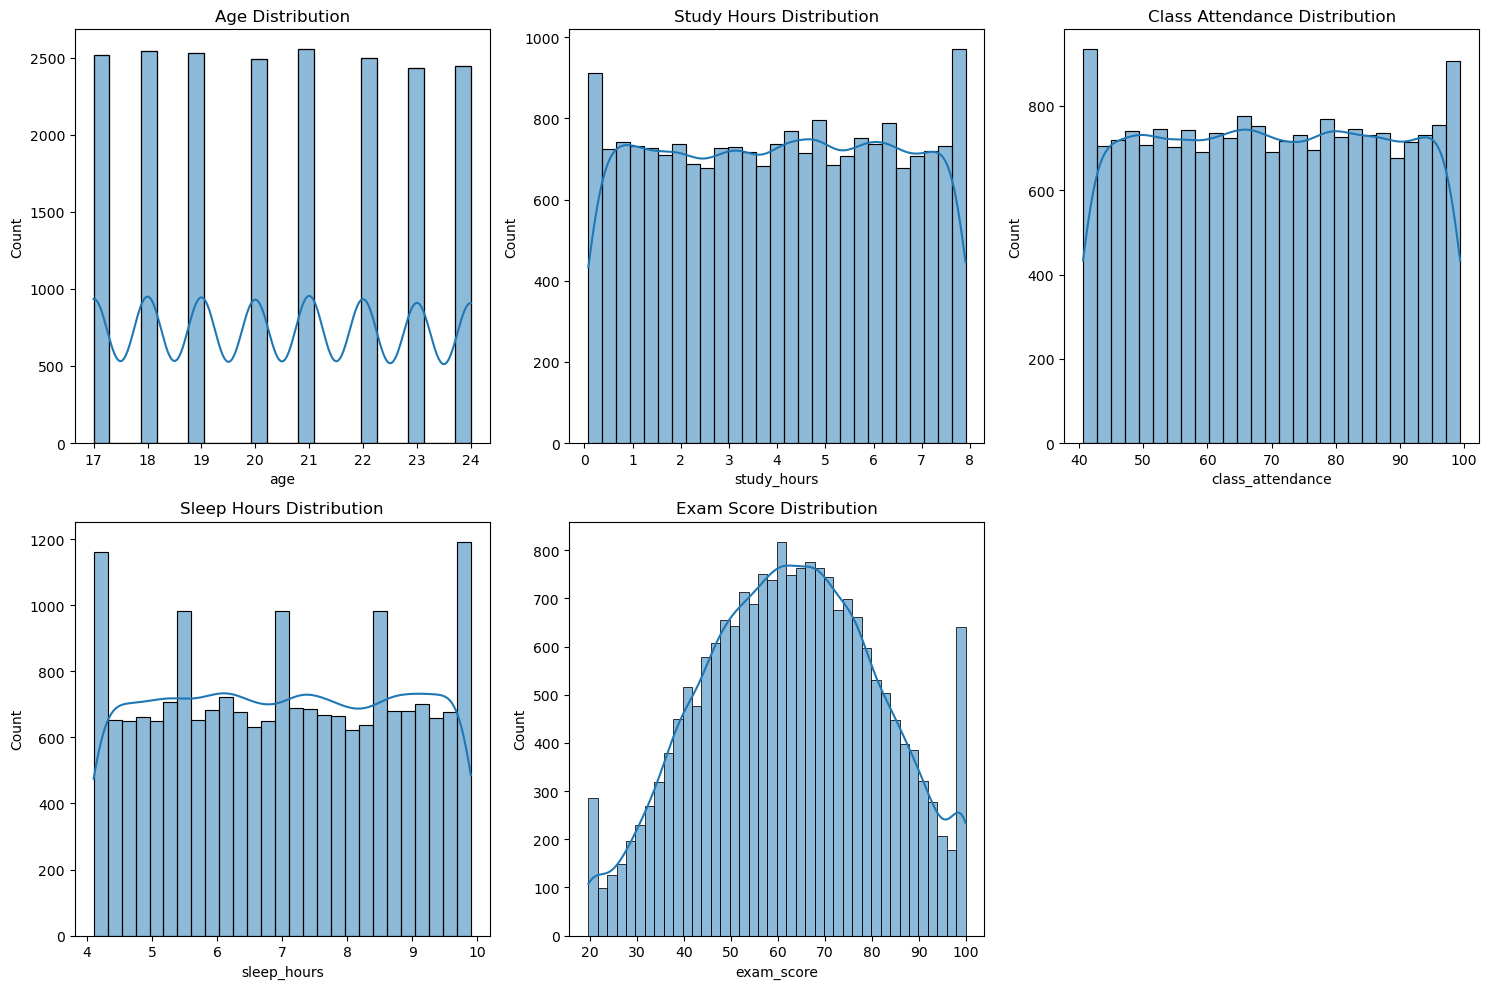

In [15]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')

plt.subplot(2, 3, 2)
sns.histplot(df['study_hours'], kde=True)
plt.title('Study Hours Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['class_attendance'], kde=True)
plt.title('Class Attendance Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['sleep_hours'], kde=True)
plt.title('Sleep Hours Distribution')

plt.subplot(2, 3, 5)
sns.histplot(df['exam_score'], kde=True)
plt.title('Exam Score Distribution')

plt.tight_layout()
plt.show()

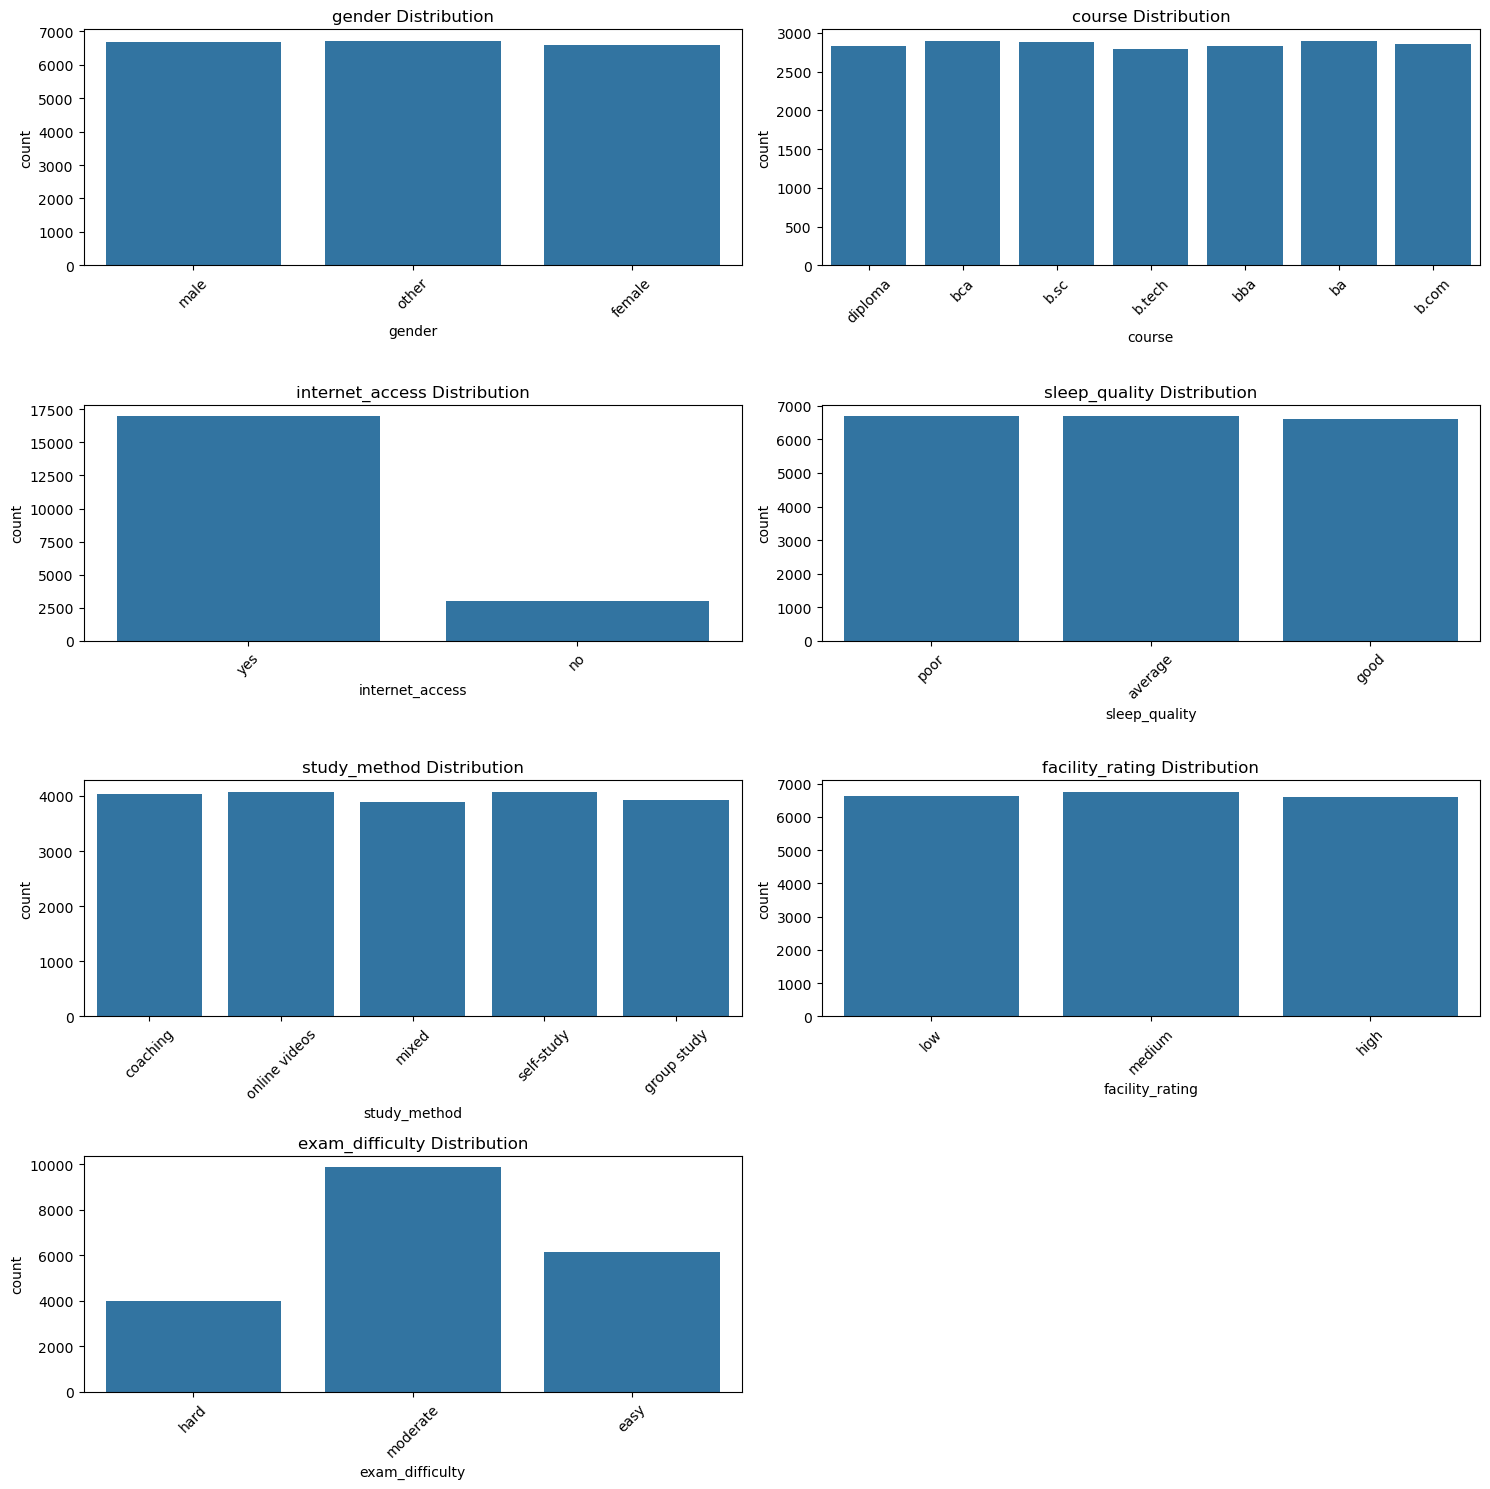

In [16]:
plt.figure(figsize=(15, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i+1)
    sns.countplot(x=df[col])
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

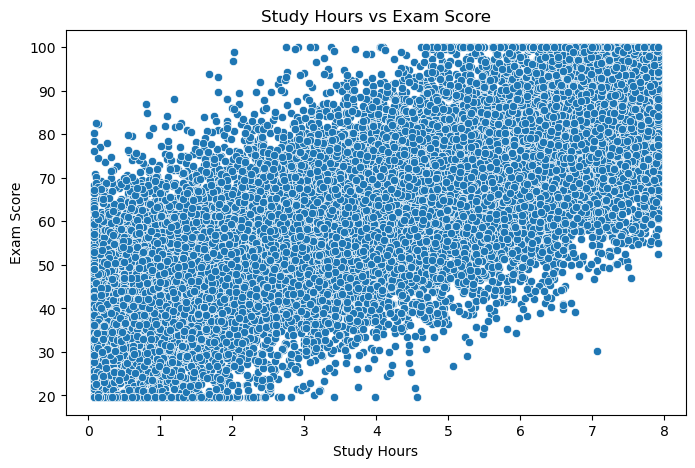

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df['study_hours'],
    y=df['exam_score']
)

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')

plt.show()

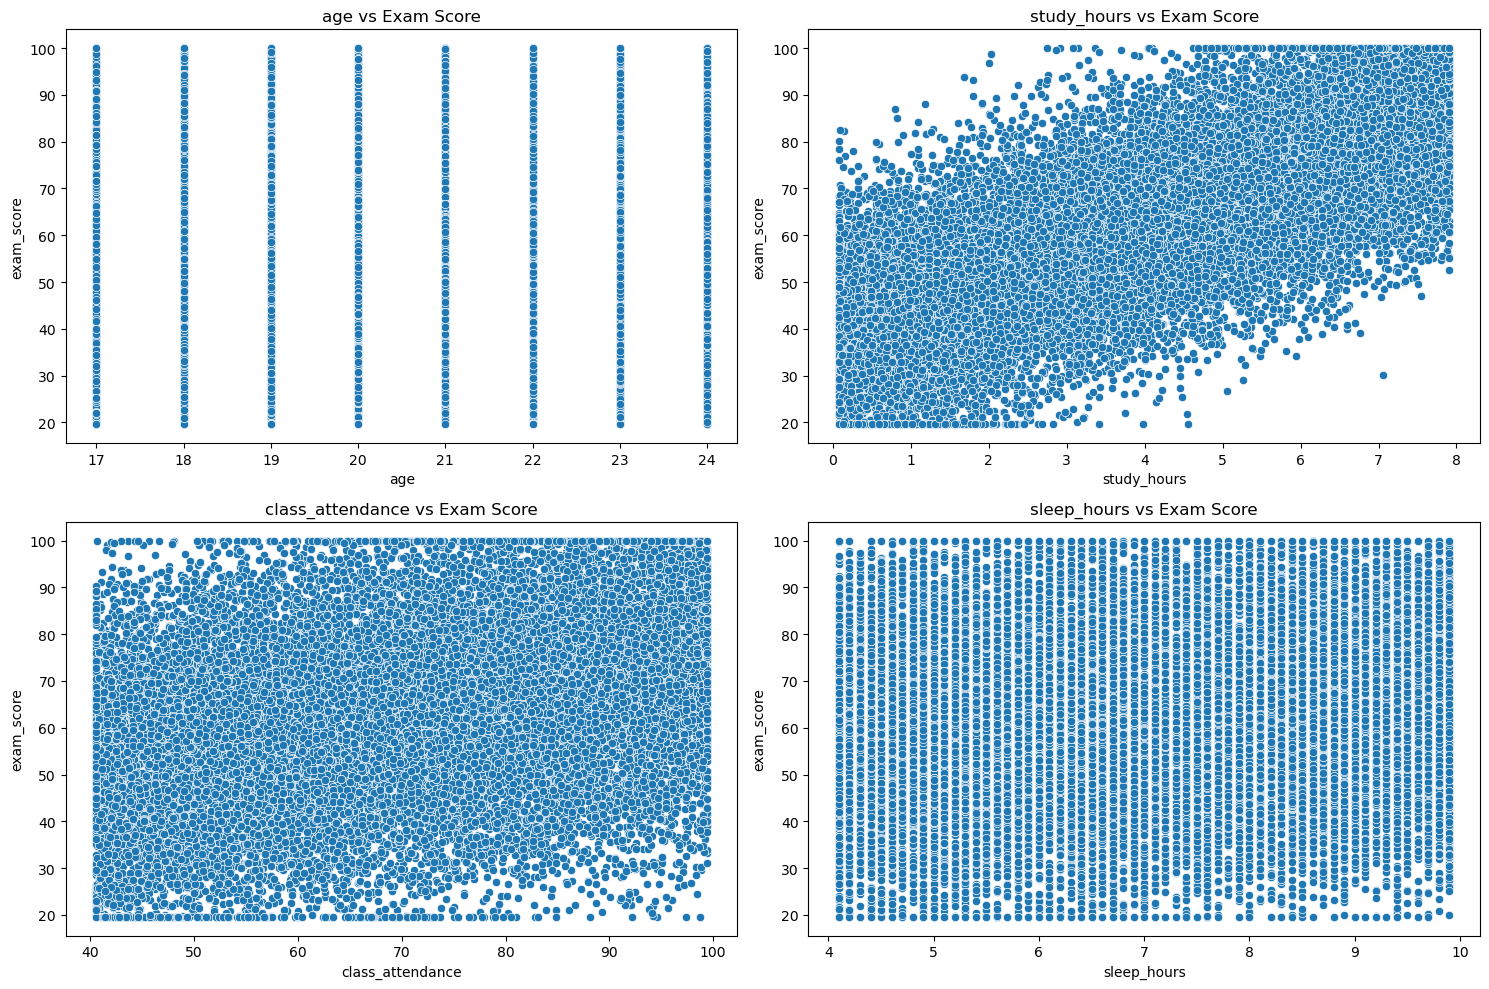

In [18]:
num_features = [
    'age',
    'study_hours',
    'class_attendance',
    'sleep_hours'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features):

    plt.subplot(2, 2, i+1)

    sns.scatterplot(
        x=df[col],
        y=df['exam_score']
    )

    plt.xlabel(col)
    plt.ylabel('exam_score')
    plt.title(f'{col} vs Exam Score')

plt.tight_layout()
plt.show()

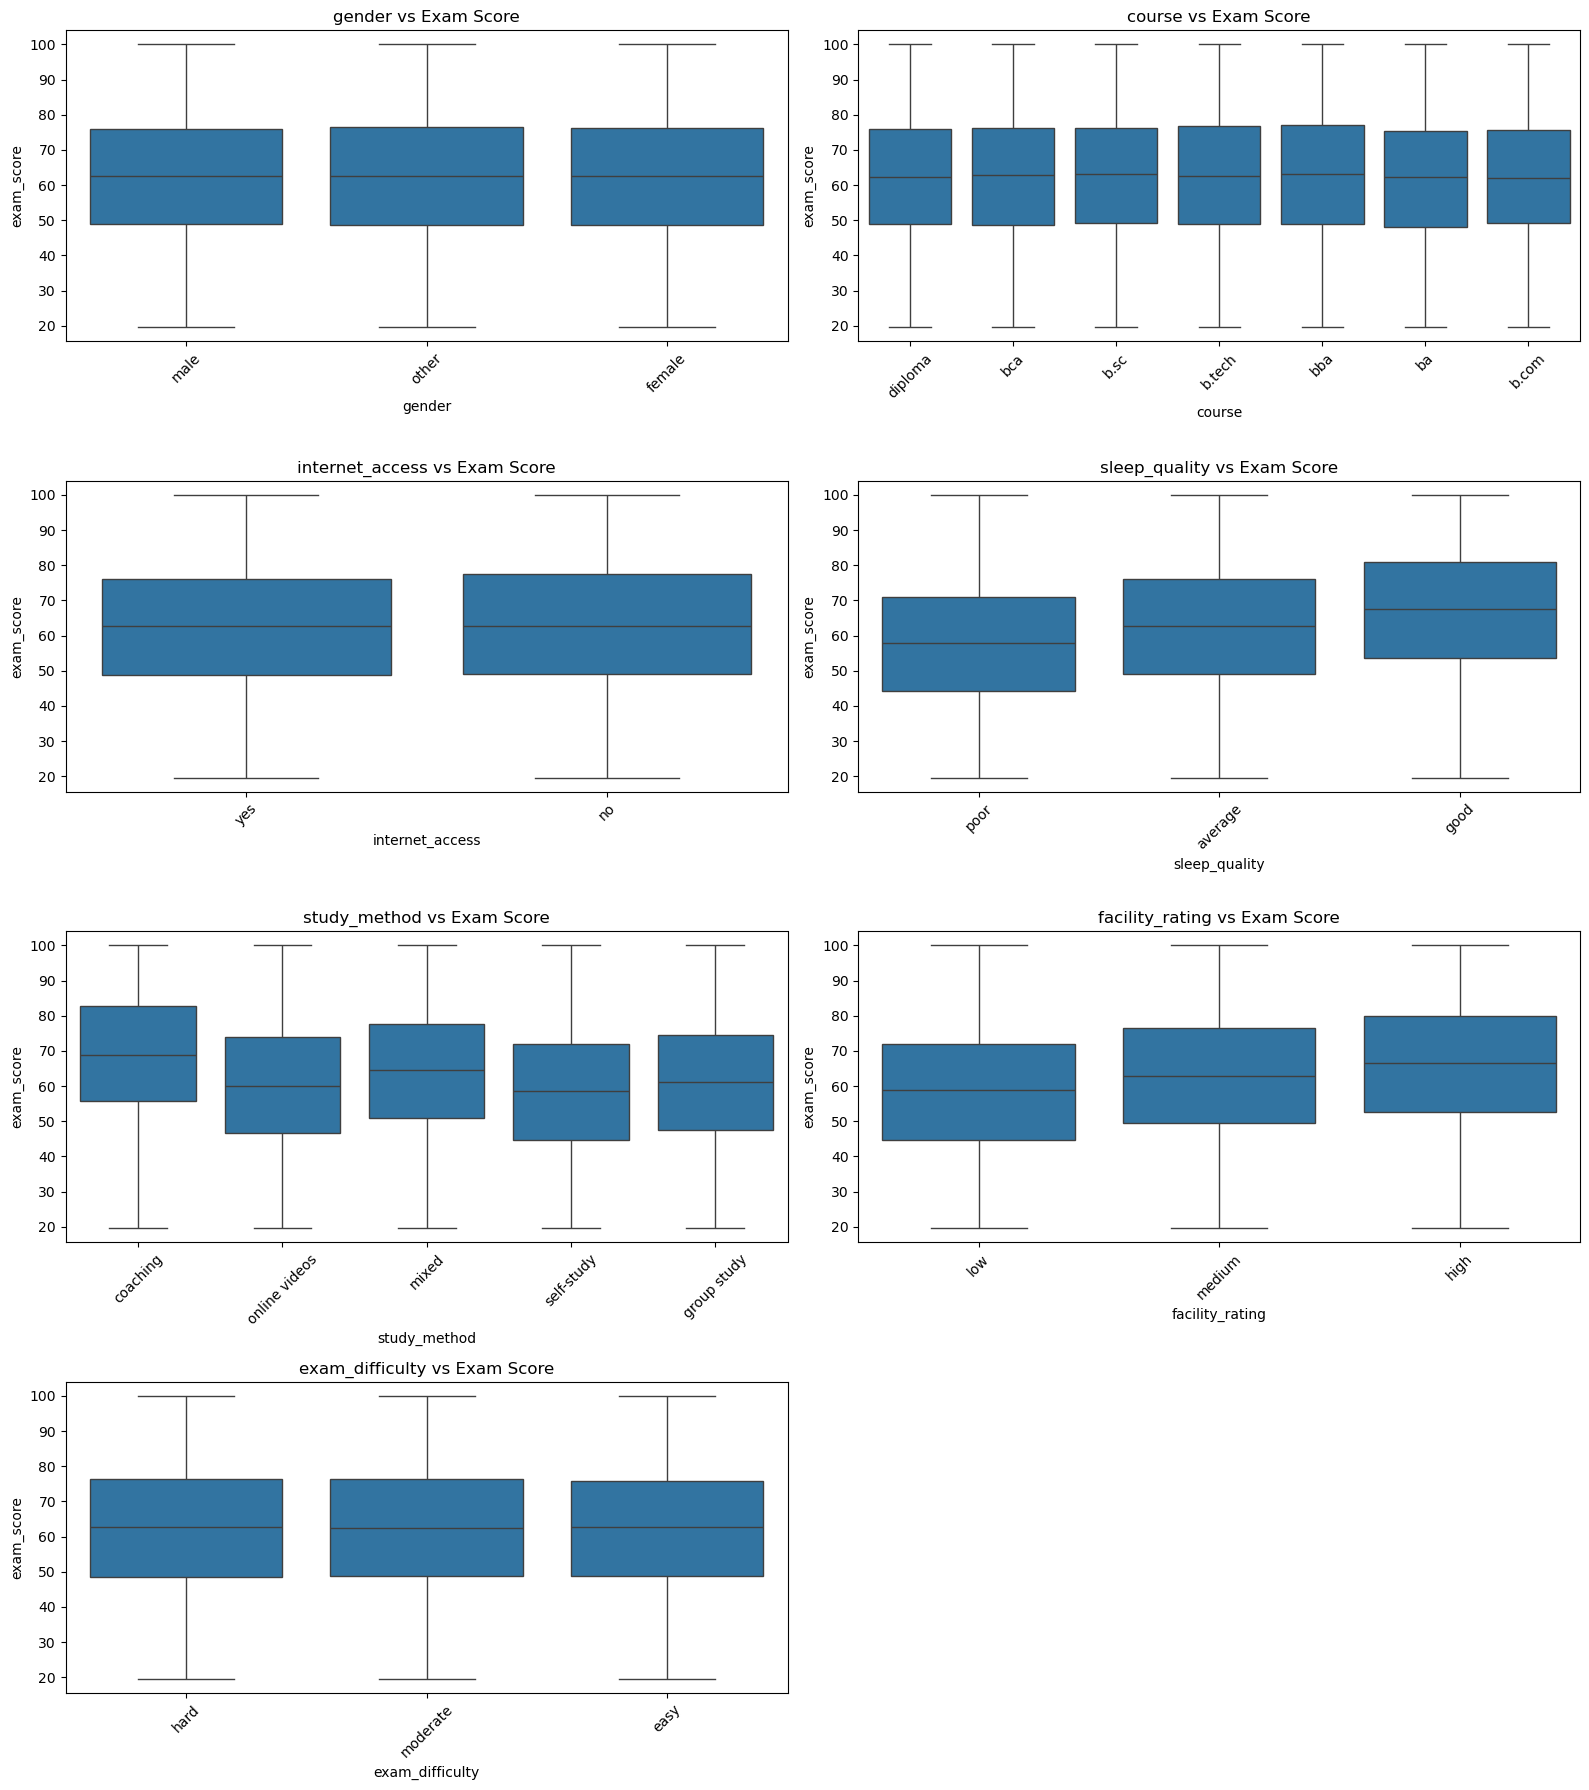

In [ ]:
cat_features = [
    'gender',
    'course',
    'internet_access',
    'sleep_quality',
    'study_method',
    'facility_rating',
    'exam_difficulty'
]

plt.figure(figsize=(16, 18))

for i, col in enumerate(cat_features):

    plt.subplot(4, 2, i+1)

    sns.boxplot(
        x=df[col],
        y=df['exam_score']
    )

    plt.title(f'{col} vs Exam Score')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

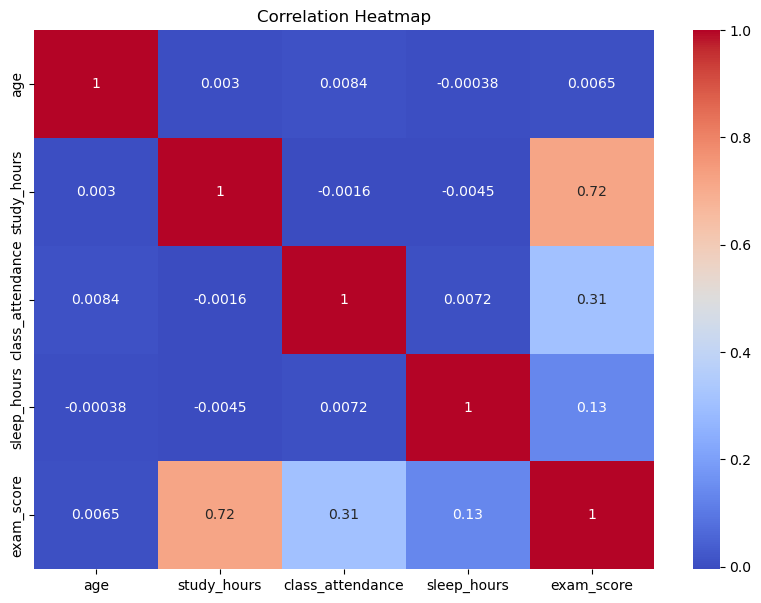

In [20]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [22]:
from scipy.stats import ttest_ind, f_oneway, pearsonr
import pandas as pd

results = []

# Categorical columns
for col in cat_features:

    groups = [
        group['exam_score'].values
        for name, group in df.groupby(col)
    ]

    if df[col].nunique() == 2:

        statistic, p_value = ttest_ind(
            groups[0],
            groups[1],
            equal_var=False
        )

        test = "Welch's t-test"

    else:

        statistic, p_value = f_oneway(*groups)

        test = "One-way ANOVA"

    results.append([
        col,
        test,
        statistic,
        p_value
    ])


# Age
correlation, p_value = pearsonr(
    df['age'],
    df['exam_score']
)

results.append([
    'age',
    'Pearson correlation',
    correlation,
    p_value
])


results_df = pd.DataFrame(
    results,
    columns=[
        'Feature',
        'Test',
        'Statistic',
        'P-value'
    ]
)

results_df

,Feature,Test,Statistic,P-value
0,gender,One-way ANOVA,0.190609,8.264568e-01
1,course,One-way ANOVA,0.614432,7.189976e-01
2,internet_access,Welch's t-test,1.093044,2.744384e-01
3,sleep_quality,One-way ANOVA,411.793336,5.560728e-176
4,study_method,One-way ANOVA,180.526693,3.198667e-152
5,facility_rating,One-way ANOVA,273.766437,5.050711e-118
6,exam_difficulty,One-way ANOVA,0.236966,7.890206e-01
7,age,Pearson correlation,0.006522,3.564025e-01


In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cat_features:
    df[col]=le.fit_transform(df[col])


In [24]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


In [35]:
X=df.drop(['exam_score','age','gender','internet_access','exam_difficulty','course'],axis=1)
y=df['exam_score']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [37]:
from sklearn.tree import DecisionTreeRegressor
model1=DecisionTreeRegressor()
model1.fit(X_train,y_train)

DecisionTreeRegressor()

In [38]:
y_pred=model1.predict(X_test)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))


0.4114624474358076
212.2460069560606
11.594546969696971


### ADABOOSTING

In [39]:
from sklearn.ensemble import AdaBoostRegressor
ada_model=AdaBoostRegressor(random_state=42)
ada_model.fit(X_train,y_train)
y_predada=ada_model.predict(X_test)
print(r2_score(y_test,y_predada))
print(mean_absolute_error(y_test,y_predada))
print(mean_squared_error(y_test,y_predada))


0.6729748250102305
8.879628460486071
117.93603868313052


### XGBOOST

In [43]:
from xgboost import XGBRegressor
model3=XGBRegressor()
model3.fit(X_train,y_train)
xgy_pred=model3.predict(X_test)
print(r2_score(y_test,xgy_pred))
print(mean_squared_error(y_test,xgy_pred))
print(mean_absolute_error(y_test,xgy_pred))

0.697496526820415
109.09270613739429
8.375954557305537


In [44]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}
from sklearn.model_selection import RandomizedSearchCV

model = XGBRegressor(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [45]:
best_m=random_search.best_estimator_
best_m.fit(X_train,y_train)
best_pred=best_m.predict(X_test)
print(r2_score(y_test,best_pred))
print(mean_squared_error(y_test,best_pred))
print(mean_absolute_error(y_test,best_pred))


0.7310658291164074
96.98651115020498
7.942119999556109
